# Label extraction

### Introduction

We don't need perfect labels here. The image model will train on ~4,349 LLM-pseudo-labeled studies, and deep nets tolerate a surprising amount of label noise without a comparable drop in test performance *as long as the noise is unbiased* (random misses that vary case-by-case, not a consistent skew in one direction). What actually caps downstream performance is **systematic** bias: a condition the labeler consistently over or under-calls. Section 2 below checks both the overall agreement rate and, specifically, whether any condition's errors are directionally biased rather than random.

### Contents

- **Calibration review** how well does each labeler agree with the 58 gold rows?
- **Detailed work-up: best model** closer look at the winning model
- **Ensemble design** two model voting approach to decrease bias
- **Pseudo-labeled dataset QA** QA of the fully-labeled dataset the Luigi pipeline produces

### Models tested

1. GTP-OSS-20B, Q4_K_M
2. Qwen2.5-14B-Instruct, Q4_K_M
3. Qwen2.5-7B-Instruct, Q4_K_M
4. Phi-4-14B, Q4_K_M
5. Llama-3.1-8B-Instruct, Q8
6. Gemma-2-9B-it, Q4_K_M

### Reading list

- Rolnick, Veit, Belongie & Shavit (2017), ["Deep Learning is Robust to Massive Label Noise"](https://arxiv.org/pdf/1705.10694): CNNs tolerate very high noise-to-signal ratios given enough data; *random* noise is far less damaging than *systematic* noise.
- Zhang, Bengio, Hardt, Recht & Vinyals (2017), ["Understanding Deep Learning Requires Rethinking Generalization"](https://arxiv.org/pdf/1611.03530) (ICLR): deep nets can memorize pure random labels, so robustness isn't unconditional; there must be real signal to lock onto alongside the noise.
- Patrini, Rozza, Krishna Menon, Nock & Qu (2017), ["Making Deep Neural Networks Robust to Label Noise: A Loss Correction Approach"](https://arxiv.org/pdf/1609.03683) (CVPR): loss-correction methods for when the noise transition matrix (i.e. directional bias) is known or estimable.
- Natarajan, Dhillon, Ravikumar & Tewari (2013), ["Learning with Noisy Labels"](https://proceedings.neurips.cc/paper_files/paper/2013/file/3871bd64012152bfb53fdf04b401193f-Paper.pdf) (NeurIPS): theoretical foundation for risk-consistent learning under class-conditional (asymmetric) label noise.
- Song, Kim, Park, Shin & Lee (2022), ["Learning from Noisy Labels with Deep Neural Networks: A Survey"](https://arxiv.org/pdf/2007.08199) (IEEE TNNLS): broad survey tying the above together.


## 1. Notebook setup

### 1.1. Imports

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import confusion_matrix, roc_curve

import configuration as config
import data_pipeline.label_extraction.config as pipeline_config # noqa: E402
from helper_funcs.label_extraction import (
    bias_severity, failed_uid_count, load_calibration_cmp, mcnemar_bias,
    multilabel_summary, per_condition_metrics, per_report_multilabel_metrics,
    run_model_name
)

### 1.2. Configuration

In [2]:
CALIBRATION_RUNS = [
    '20260909_gpt20B',
    '20260909_qwen14B',
    '20260909_qwen7B',
    '20260909_phi4',
    '20260909_llama8B',
    '20260909_gemma9B'
]

### 1.3. Reference: local inference server deployment settings

Six candidate deployments on 2x P100 (16GB each), one identical process per GPU (`CUDA_VISIBLE_DEVICES=0` → port 8503, `=1` → port 8504).

**Context sizing:** `llama-server` splits `--ctx-size` evenly across `--parallel` slots. The original settings gave only ~2048 tokens/slot, not enough for the system prompt (multilingual glossary for 12 conditions) + few-shot exemplar + structured-output JSON schema. The `20260909_qwen14B` calibration run hit repeated `Context size has been exceeded` (HTTP 500) on longer, mostly non-English gold reports. Settings below now target ~4096 tokens/slot across the board.

#### GPT-OSS-20B 

**current MoE baseline**: `--parallel 12` + `--workers 24` confirmed via `nvidia-smi dmon -s um`: `sm` ~98%, with `mem` in the teens, so this is now compute-bound, not memory-bandwidth-bound.

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model gpt-oss-20b-Q4_K_M.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 49152 --parallel 12 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Qwen2.5-14B-Instruct

**My guess for the winner**: structured output + multilingual. With full f16 K & V cache, and 40960 context we OOM on the P100s. Decreased to parallel 8 x 4096 tokens = 32768 total context. Could probably get away with 9 slots per card, but it's tight.

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model Qwen2.5-14B-Instruct-Q4_K_M.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 32768 --parallel 8 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Qwen2.5-7B-Instruct

**Ensemble partner (model_b), as deployed**: originally run at `--parallel 12` for the solo calibration trial, but for the two-model ensemble deployment (its own dedicated GPU, paired with phi4 on the other - no more identical-replica round-robin pair) backed off to `--parallel 4`, same reasoning as phi4 below: fewer concurrent slots means less prefill contention per decode step, and stability matters more than raw throughput once there's no second replica to fall back on. Live on port 8503, `--ctx-size 16384` (4 x 4096/slot).

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model Qwen2.5-7B-Instruct-Q8_0.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 16384 --parallel 4 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Phi-4 (14B)

**Ensemble partner (model_a), as deployed**: fails with CUDA OOM at 40960 context and 10 slots per card. `--parallel 6` (32768 ctx-size) hit `Context size has been exceeded`. After that increasing the total context `nvidia-smi dmon -s um` showed `sm` pinned at ~100% with `mem` only ~20% - compute-bound, not memory-bound: continuous batching was spending most of its time on prefill with 6 concurrent slots/card, starving decode. Live ensemble deployment matches qwen7B's slot count: port 8504, `--ctx-size 16384 --parallel 4`.

```bash
CUDA_VISIBLE_DEVICES=1 ./llama-server \
  --model phi-4-Q4_K_M.gguf \
  --port 8504 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 16384 --parallel 4 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Llama-3.1-8B-Instruct

Meta lineage, a classic. Context 49152 gives ~14.1 GB VRAM consumed per card, plenty of room - but probably not enough for more than one additional slot per card.

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model Meta-Llama-3.1-8B-Instruct-Q8_0.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 49152 --parallel 12 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

#### Gemma-2-9B-it

Google lineage, strong instruction following at small size. CUDA OOM with 40960 context and 10 slots. Had to reduce to 28672 and 7 slots - puts us at 15.6 GB VRAM, about as tight as it gets...

```bash
CUDA_VISIBLE_DEVICES=0 ./llama-server \
  --model gemma-2-9b-it-Q4_K_M.gguf \
  --port 8503 --host 0.0.0.0 \
  --n-gpu-layers 999 \
  --ctx-size 28672 --parallel 7 \
  --cont-batching \
  --batch-size 512 --ubatch-size 512 \
  --api-key "$LOCAL_API_KEY"
```

**Marking a calibration trial by model:** encode the model into the run id when calibrating (e.g. `--run 20260909_qwen14b`, `--run 20260909_gptoss20b`), `RunCalibration` also writes `run_meta.json` (model name, server URLs, samples-per-report, completion time) into the run directory for provenance, so a run's model doesn't rely on naming discipline alone.

**Recovering a run with context-overflow rows:** after redeploying with a bigger `--ctx-size`, delete just the affected rows and the `_complete` file in the `calibration_rows/` directory so Luigi re-does them (their existing output files satisfy the target check otherwise): `rm data/pipeline/label_extraction/<run_id>/calibration_rows/{uid}.json` for each `uid` listed in `data/pipeline/label_extraction/<run_id>/failed_uids.txt`, then re-run `python3 -m data_pipeline.pipeline calibrate --run <run_id>`.

Repeat each command with `CUDA_VISIBLE_DEVICES=1 --port 8504` for the second identical server. If `--parallel` changes, update `SLOTS_PER_LOCAL_SERVER` in `config.py` to match, and pass `--workers <2 x parallel>` on the CLI (e.g. `--workers 24` for GPT-OSS-20B at `--parallel 12`, `--workers 20` for the 14B models at `--parallel 10`) so enough requests are in flight to actually use the extra slots.

## 2. Calibration review

Multi-model first: load every calibration trial, score them all the same way, compare, then dig into the best one.

### 2.1. Load gold training labels

In [3]:
# Gold rows (58 studies with original labels) - the fixed reference every
# trial is compared against.
raw = pd.read_csv(config.TRAIN_CSV)
label_cols = [c for c in raw.columns if c not in ('StudyInstanceUID', 'Report')]
gold_mask = raw[label_cols].notna().any(axis=1)
gold = raw[gold_mask].set_index('StudyInstanceUID')

print(f'{len(gold)} gold rows, {len(label_cols)} conditions')

58 gold rows, 12 conditions


### 2.2. Load and parse calibration runs

In [4]:
# List every calibration trial to compare (one run id per model/deployment -
# see section 1.3). Add new run ids here as they complete.
cmp = {r: load_calibration_cmp(r, label_cols, gold) for r in CALIBRATION_RUNS}

for r in CALIBRATION_RUNS:
    meta_f = pipeline_config.OUTPUT_ROOT / r / 'run_meta.json'

    if meta_f.exists() is False:
        print(f'--- {r}: no run_meta.json (older run, predates provenance tracking) ---')

    n_failed = failed_uid_count(r)
    warn = f' -- WARNING: {n_failed} rows failed (see failed_uids.txt) and load as empty predictions' if n_failed else ''
    print(f'Run {r}: {len(cmp[r])} rows loaded{warn}')

Run 20260909_gpt20B: 58 rows loaded
Run 20260909_qwen14B: 58 rows loaded
Run 20260909_qwen7B: 58 rows loaded -- WARNING: 2 rows failed (see failed_uids.txt) and load as empty predictions
Run 20260909_phi4: 58 rows loaded
Run 20260909_llama8B: 58 rows loaded
Run 20260909_gemma9B: 58 rows loaded


### 2.3. Score metrics per model

Per-condition accuracy, Cohen's kappa, ROC AUC and average precision for every trial. **Caveat:** the labeler emits a hard 0/1 vote per condition, not a probability, so ROC AUC here collapses to `0.5 * (TPR + TNR)` (balanced accuracy) rather than a true ranking-based AUC, and it's measured against only 58 gold *report-text* rows - not directly comparable to a competition leaderboard AUC (continuous-probability *image* model, much larger test set). Treat these as a sanity-check floor on label quality, not a proxy for achievable leaderboard score.

In [5]:
metrics_by_run = {r: per_condition_metrics(cmp[r], label_cols) for r in CALIBRATION_RUNS}

for r in CALIBRATION_RUNS:
    m = metrics_by_run[r]
    print(
        f'{r}: mean accuracy={m["accuracy"].mean():.3f} '
        f'| mean kappa={m["kappa"].mean():.3f} | mean roc_auc={m["roc_auc"].mean():.3f}'
    )

    display(metrics_by_run[r].round(3))

20260909_gpt20B: mean accuracy=0.807 | mean kappa=0.568 | mean roc_auc=0.805


,gold_pos,pred_pos,accuracy,kappa,roc_auc,avg_precision,false_neg,false_pos
condition,,,,,,,,
ACL,24,33,0.845,0.697,0.868,0.727,0,9
MCL,9,17,0.862,0.614,0.918,0.529,0,8
Medial Meniscus,26,30,0.828,0.656,0.833,0.730,3,7
Lateral Meniscus,23,23,0.862,0.712,0.856,0.751,4,4
Medial OA,15,18,0.879,0.705,0.875,0.660,2,5
Lateral OA,11,16,0.845,0.570,0.835,0.495,2,7
PF OA,21,22,0.741,0.446,0.725,0.545,7,8
Effusion,35,50,0.741,0.392,0.674,0.700,0,15
Synovitis,27,16,0.672,0.324,0.658,0.592,15,4


20260909_qwen14B: mean accuracy=0.797 | mean kappa=0.555 | mean roc_auc=0.808


,gold_pos,pred_pos,accuracy,kappa,roc_auc,avg_precision,false_neg,false_pos
condition,,,,,,,,
ACL,24,29,0.879,0.759,0.891,0.777,1,6
MCL,9,20,0.810,0.517,0.888,0.450,0,11
Medial Meniscus,26,30,0.862,0.725,0.868,0.773,2,6
Lateral Meniscus,23,28,0.776,0.549,0.784,0.630,4,9
Medial OA,15,23,0.828,0.617,0.862,0.585,1,9
Lateral OA,11,24,0.741,0.421,0.806,0.396,1,14
PF OA,21,21,0.793,0.552,0.776,0.614,6,6
Effusion,35,50,0.707,0.310,0.638,0.678,1,16
Synovitis,27,26,0.741,0.479,0.739,0.652,8,7


20260909_qwen7B: mean accuracy=0.810 | mean kappa=0.566 | mean roc_auc=0.801


...

,gold_pos,pred_pos,accuracy,kappa,roc_auc,avg_precision,false_neg,false_pos
condition,,,,,,,,
ACL,24,29,0.879,0.759,0.891,0.777,1,6
MCL,9,16,0.879,0.651,0.929,0.562,0,7
Medial Meniscus,26,31,0.879,0.760,0.887,0.793,1,6
Lateral Meniscus,23,26,0.845,0.683,0.849,0.721,3,6
Medial OA,15,18,0.879,0.705,0.875,0.660,2,5
Lateral OA,11,14,0.845,0.543,0.800,0.467,3,6
PF OA,21,22,0.810,0.594,0.800,0.640,5,6
Effusion,35,49,0.724,0.356,0.660,0.691,1,15
Synovitis,27,17,0.690,0.361,0.676,0.610,14,4


20260909_llama8B: mean accuracy=0.783 | mean kappa=0.515 | mean roc_auc=0.776


,gold_pos,pred_pos,accuracy,kappa,roc_auc,avg_precision,false_neg,false_pos
condition,,,,,,,,
ACL,24,39,0.638,0.316,0.673,0.523,3,18
MCL,9,23,0.759,0.437,0.857,0.391,0,14
Medial Meniscus,26,30,0.828,0.656,0.833,0.730,3,7
Lateral Meniscus,23,25,0.759,0.503,0.755,0.606,6,8
Medial OA,15,15,0.862,0.640,0.820,0.607,4,4
Lateral OA,11,16,0.810,0.474,0.779,0.415,3,8
PF OA,21,18,0.741,0.422,0.705,0.536,9,6
Effusion,35,47,0.724,0.367,0.667,0.696,2,14
Synovitis,27,21,0.724,0.438,0.716,0.641,11,5


20260909_gemma9B: mean accuracy=0.816 | mean kappa=0.589 | mean roc_auc=0.819


,gold_pos,pred_pos,accuracy,kappa,roc_auc,avg_precision,false_neg,false_pos
condition,,,,,,,,
ACL,24,33,0.845,0.697,0.868,0.727,0,9
MCL,9,18,0.845,0.580,0.908,0.500,0,9
Medial Meniscus,26,32,0.862,0.727,0.871,0.768,1,7
Lateral Meniscus,23,29,0.759,0.517,0.770,0.610,4,10
Medial OA,15,19,0.931,0.835,0.953,0.789,0,4
Lateral OA,11,16,0.845,0.570,0.835,0.495,2,7
PF OA,21,22,0.810,0.594,0.800,0.640,5,6
Effusion,35,49,0.724,0.356,0.660,0.691,1,15
Synovitis,27,17,0.690,0.361,0.676,0.610,14,4


### 2.4. McNemar's test per model (directional bias)

[McNemar's exact test](https://en.wikipedia.org/wiki/McNemar%27s_test): gold and the LLM are two paired raters scoring the same 58 studies. Random disagreements (sometimes gold-only, sometimes LLM-only, roughly balanced) tend to average out during downstream training. Systematic bias (e.g. "the LLM almost always calls this condition when gold doesn't") does not; it teaches the image model a consistent skew. This checks, per condition per trial, whether the two types of discordant pairs (gold=0/LLM=1 vs gold=1/LLM=0) are significantly different from a 50/50 split; a small p-value with a lopsided ratio flags directional bias rather than noise.

In [6]:
bias_by_run = {r: mcnemar_bias(cmp[r], label_cols) for r in CALIBRATION_RUNS}

for r in CALIBRATION_RUNS:
    n_sig = int((bias_by_run[r]['mcnemar_p'] < 0.05).sum())
    print(f'{r}: {n_sig}/{len(label_cols)} conditions with significant directional bias')

    display(bias_by_run[r])

20260909_gpt20B: 5/12 conditions with significant directional bias


,false_pos,false_neg,n_discordant,bias_direction,mcnemar_p,flag
condition,,,,,,
Effusion,15,0,15,over-calls,0.000061,*** significant bias ***
ACL,9,0,9,over-calls,0.003906,*** significant bias ***
MCL,8,0,8,over-calls,0.007812,*** significant bias ***
Synovitis,4,15,19,under-calls,0.019211,*** significant bias ***
Contusion,15,4,19,over-calls,0.019211,*** significant bias ***
Lateral OA,7,2,9,over-calls,0.179688,
Baker's,5,1,6,over-calls,0.218750,
Medial Meniscus,7,3,10,over-calls,0.343750,
Medial OA,5,2,7,over-calls,0.453125,


20260909_qwen14B: 5/12 conditions with significant directional bias


,false_pos,false_neg,n_discordant,bias_direction,mcnemar_p,flag
condition,,,,,,
Effusion,16,1,17,over-calls,0.000275,*** significant bias ***
MCL,11,0,11,over-calls,0.000977,*** significant bias ***
Lateral OA,14,1,15,over-calls,0.000977,*** significant bias ***
Contusion,14,2,16,over-calls,0.004181,*** significant bias ***
Medial OA,9,1,10,over-calls,0.021484,*** significant bias ***
ACL,6,1,7,over-calls,0.125000,
Baker's,6,1,7,over-calls,0.125000,
Lateral Meniscus,9,4,13,over-calls,0.266846,
Medial Meniscus,6,2,8,over-calls,0.289062,


20260909_qwen7B: 3/12 conditions with significant directional bias


...

,false_pos,false_neg,n_discordant,bias_direction,mcnemar_p,flag
condition,,,,,,
Effusion,15,1,16,over-calls,0.000519,*** significant bias ***
MCL,7,0,7,over-calls,0.015625,*** significant bias ***
Synovitis,4,14,18,under-calls,0.030884,*** significant bias ***
Contusion,11,4,15,over-calls,0.118469,
ACL,6,1,7,over-calls,0.125000,
Medial Meniscus,6,1,7,over-calls,0.125000,
Baker's,6,1,7,over-calls,0.125000,
Medial OA,5,2,7,over-calls,0.453125,
Lateral Meniscus,6,3,9,over-calls,0.507812,


20260909_llama8B: 3/12 conditions with significant directional bias


,false_pos,false_neg,n_discordant,bias_direction,mcnemar_p,flag
condition,,,,,,
MCL,14,0,14,over-calls,0.000122,*** significant bias ***
ACL,18,3,21,over-calls,0.001490,*** significant bias ***
Effusion,14,2,16,over-calls,0.004181,*** significant bias ***
Synovitis,5,11,16,under-calls,0.210114,
Baker's,5,1,6,over-calls,0.218750,
Lateral OA,8,3,11,over-calls,0.226562,
Medial Meniscus,7,3,10,over-calls,0.343750,
PF OA,6,9,15,under-calls,0.607239,
Lateral Meniscus,8,6,14,over-calls,0.790527,


20260909_gemma9B: 5/12 conditions with significant directional bias


,false_pos,false_neg,n_discordant,bias_direction,mcnemar_p,flag
condition,,,,,,
Effusion,15,1,16,over-calls,0.000519,*** significant bias ***
ACL,9,0,9,over-calls,0.003906,*** significant bias ***
MCL,9,0,9,over-calls,0.003906,*** significant bias ***
Synovitis,4,14,18,under-calls,0.030884,*** significant bias ***
Contusion,12,3,15,over-calls,0.035156,*** significant bias ***
Medial Meniscus,7,1,8,over-calls,0.070312,
Medial OA,4,0,4,over-calls,0.125000,
Lateral Meniscus,10,4,14,over-calls,0.179565,
Lateral OA,7,2,9,over-calls,0.179688,


### 2.5. Multi-label agreement

Per-report multi-label agreement for all six v1 trials. Per-condition metrics (2.3) score each condition's marginal accuracy independently, which can hide a labeler that's fine on average per-condition but never gets the *combination* right on any single report. This checks, per model:

- Does the predicted positive-condition set match gold exactly
- Does it at least have the right count of positives
- How much overlap is there between positive predictions (Jaccard) when it's wrong
- What's the mean difference between the number of anomalies detected and the real number

In [7]:
multilabel_by_run = {r: per_report_multilabel_metrics(cmp[r], label_cols) for r in CALIBRATION_RUNS}

ml_summary_tbl = pd.DataFrame({
    r: multilabel_summary(multilabel_by_run[r]) for r in CALIBRATION_RUNS
}).T
ml_summary_tbl.index.name = 'run_id'
ml_summary_tbl.round(3)

,exact_match_rate,count_match_rate,mean_jaccard,mean_count_diff
run_id,,,,
20260909_gpt20B,0.103,0.241,0.588,0.828
20260909_qwen14B,0.103,0.172,0.585,1.293
20260909_qwen7B,0.121,0.190,0.595,0.517
20260909_phi4,0.155,0.224,0.617,0.741
20260909_llama8B,0.121,0.190,0.564,0.810
20260909_gemma9B,0.103,0.207,0.607,0.966


### 2.6. Compare performance across models

Ranks by a blended `combined_score = mean_roc_auc - BIAS_WEIGHT * bias_severity` rather than mean ROC AUC alone. The smooth trade-off avoids the cliff a hard cutoff would create between two runs that are nearly tied on accuracy but treated as entirely non-comparable on bias (or vice versa).

In [8]:
# BIAS_WEIGHT: converts bias_severity into ROC-AUC-equivalent units for a
# single blended score, avoiding a hard cutoff's cliff effect (two runs a
# hair's-width apart in ROC AUC could otherwise be ranked by entirely
# different criteria). Strict ROC-AUC-parity value (0.005) - phi4 wins on
# both per-condition and multi-label agreement at this weight already, so
# there's no need to inflate it further to penalize bias.
BIAS_WEIGHT = 0.005

compare_tbl = pd.DataFrame([
    {
        'run_id': r,
        'mean_accuracy': metrics_by_run[r]['accuracy'].mean(),
        'mean_kappa': metrics_by_run[r]['kappa'].mean(),
        'mean_roc_auc': metrics_by_run[r]['roc_auc'].mean(),
        'mean_ap': metrics_by_run[r]['avg_precision'].mean(),
        'n_significant_bias': int((bias_by_run[r]['mcnemar_p'] < 0.05).sum()),
        'bias_severity': bias_severity(bias_by_run[r]),
    }
    for r in CALIBRATION_RUNS
]).set_index('run_id')

compare_tbl['combined_score'] = compare_tbl['mean_roc_auc'] - BIAS_WEIGHT * compare_tbl['bias_severity']
compare_tbl = compare_tbl.sort_values('combined_score', ascending=False)

BEST_RUN = compare_tbl.index[0]
print(f'Best model by combined_score (mean ROC AUC - {BIAS_WEIGHT} x bias_severity): {BEST_RUN}')

compare_tbl.round(3)

Best model by combined_score (mean ROC AUC - 0.005 x bias_severity): 20260909_phi4


,mean_accuracy,mean_kappa,mean_roc_auc,mean_ap,n_significant_bias,bias_severity,combined_score
run_id,,,,,,,
20260909_phi4,0.826,0.603,0.821,0.644,3,6.601,0.788
20260909_qwen7B,0.810,0.566,0.801,0.619,3,5.008,0.776
20260909_gemma9B,0.816,0.589,0.819,0.638,5,11.066,0.763
20260909_gpt20B,0.807,0.568,0.805,0.623,5,12.163,0.744
20260909_qwen14B,0.797,0.555,0.808,0.608,5,13.628,0.740
20260909_llama8B,0.783,0.515,0.776,0.586,3,9.119,0.730


In [9]:
# Per-condition ROC AUC, one column per trial - shows which conditions
# drive any gap between candidate models rather than just the average.
pd.DataFrame({
    f'{r}': metrics_by_run[r]['roc_auc']
    for r in CALIBRATION_RUNS
}).round(3)

,20260909_gpt20B,20260909_qwen14B,20260909_qwen7B,20260909_phi4,20260909_llama8B,20260909_gemma9B
condition,,,,,,
ACL,0.868,0.891,0.879,0.891,0.673,0.868
MCL,0.918,0.888,0.853,0.929,0.857,0.908
Medial Meniscus,0.833,0.868,0.840,0.887,0.833,0.871
Lateral Meniscus,0.856,0.784,0.777,0.849,0.755,0.770
Medial OA,0.875,0.862,0.897,0.875,0.820,0.953
Lateral OA,0.835,0.806,0.824,0.800,0.779,0.835
PF OA,0.725,0.776,0.732,0.800,0.705,0.800
Effusion,0.674,0.638,0.675,0.660,0.667,0.660
Synovitis,0.658,0.739,0.679,0.676,0.716,0.676


## 3. Detailed work-up: best model

Confusion matrices, ROC curves, per-condition error drilldown, and multi-label agreement for `BEST_RUN` only (set by section 2.4).

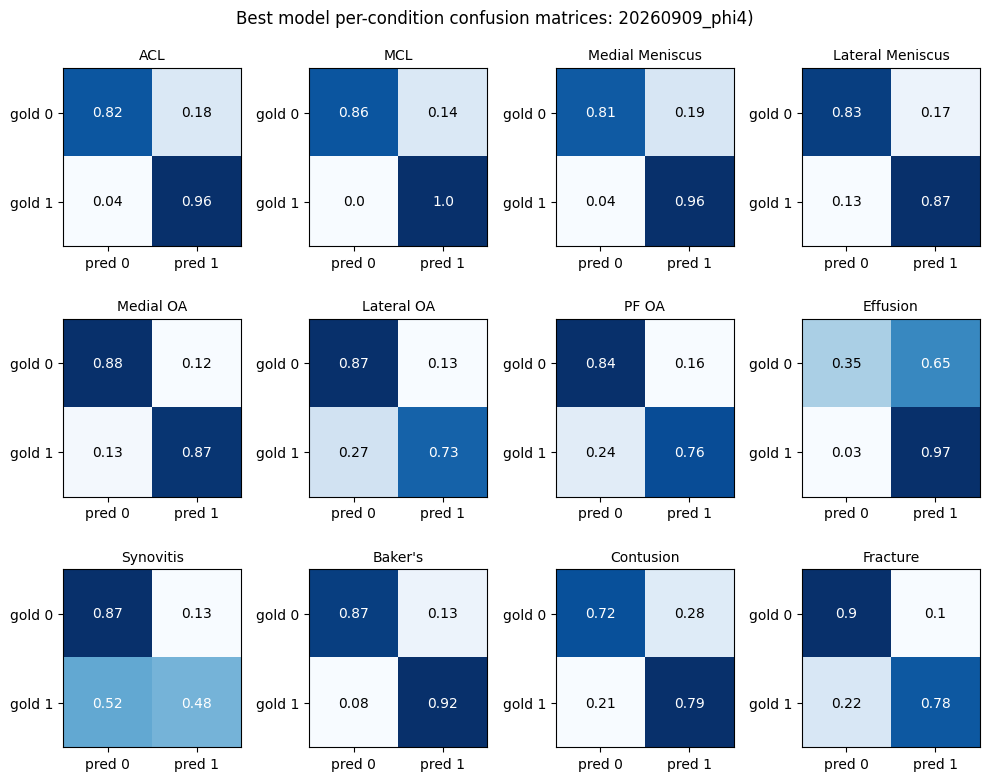

In [10]:
best_df = cmp[BEST_RUN]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, c in zip(axes.flat, label_cols):
    g = (best_df[f'{c}_label'].fillna(0) == 1).astype(int).values
    p = (best_df[f'{c}_pred'].fillna(0) == 1).astype(int).values
    cm = confusion_matrix(g, p, labels=[0, 1], normalize='true')

    ax.imshow(cm, cmap='Blues')
    ax.set_title(c, fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['gold 0', 'gold 1'])

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, round(cm[i, j], 2), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

fig.suptitle(f'Best model per-condition confusion matrices: {BEST_RUN})')
fig.tight_layout()
plt.show()

In [11]:
# Worst-matching reports for BEST_RUN - lowest Jaccard first (predicted set
# most disjoint from gold), regardless of whether the count happened to match.
multilabel_by_run[BEST_RUN].sort_values('jaccard').head(10)

,gold_count,pred_count,count_match,exact_match,jaccard
StudyInstanceUID,,,,,
1.2.826.0.1.3680043.8.498.94433753471890306108089557761231739312,1,0,False,False,0.000000
1.2.826.0.1.3680043.8.498.77362718298550276679350855963451855003,4,2,False,False,0.200000
1.2.826.0.1.3680043.8.498.54977581323931277817074741182670080450,1,5,False,False,0.200000
1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,2,3,False,False,0.250000
1.2.826.0.1.3680043.8.498.48348615349418615469875801439348424274,1,4,False,False,0.250000
1.2.826.0.1.3680043.8.498.28925345859498351203477642741908452608,5,4,False,False,0.285714
1.2.826.0.1.3680043.8.498.73926443729786165628848843707532839995,4,4,True,False,0.333333
1.2.826.0.1.3680043.8.498.72853333220043794904856138561095171921,1,3,False,False,0.333333
1.2.826.0.1.3680043.8.498.12978510157202852202776899910529174803,1,3,False,False,0.333333


## 4. Two-model ensemble: phi4 + qwen7B

Prompt v2 (an Effusion-scoped "read the whole report body" rule, derived from `BEST_RUN`'s own round-1 errors) was tried and dropped: it traded a small Effusion FN win for a worse MCL/Effusion FP rate elsewhere, and a deeper look at the remaining errors showed most of them are gold-label noise or ambiguity (identical phrasing labeled positive in one report and negative in another, or no supporting text at all) rather than something prompt wording can fix. Dropped the idea of improving the prompt further - it just introduces MORE bias.

Section 2.4 showed phi4 and qwen7B have different, only partially-overlapping directional biases (e.g. both over-call Effusion, but qwen7B is closer to symmetric on it and on MCL). Since the two models don't make identical mistakes, combining their votes per condition, rather than picking one model globally, is worth testing before any further prompt tuning.

### 4.1. Per-condition combination policy sweep

For each condition, compare 4 labeling policies built from each model's existing single-vote prediction: 

- phi4 alone
- qwen7B alone,
- **AND**: both must say positive
- **OR**: either says positive

Then choose the best policy by McNemar p-value (least directional bias), break any ties by overall accuracy of the policy.

In [12]:
from statsmodels.stats.contingency_tables import mcnemar as _mcnemar

PHI4_RUN, QWEN7B_RUN = '20260909_phi4', '20260909_qwen7B'

ens_policies = {
    'phi4':   lambda p, q: p,
    'qwen7B': lambda p, q: q,
    'AND':    lambda p, q: 1 if (p == 1 and q == 1) else 0,
    'OR':     lambda p, q: 1 if (p == 1 or q == 1) else 0,
}

def _policy_metrics(cond, policy):
    gv = cmp[PHI4_RUN][f'{cond}_label'].astype(int).values

    pv = np.array([
        policy(int(p), int(q)) for p, q in
        zip(cmp[PHI4_RUN][f'{cond}_pred'], cmp[QWEN7B_RUN][f'{cond}_pred'])
    ])

    fp = int(((gv == 0) & (pv == 1)).sum())
    fn = int(((gv == 1) & (pv == 0)).sum())
    acc = float((gv == pv).mean())
    n_disc = fp + fn
    pval = _mcnemar([[0, fn], [fp, 0]], exact=True).pvalue if n_disc else float('nan')

    return fp, fn, acc, pval

sweep_recs = []
best_policy_by_cond = {}

for cond in label_cols:
    results = {name: _policy_metrics(cond, pol) for name, pol in ens_policies.items()}

    best_policy_by_cond[cond] = max(
        results, key=lambda k: (results[k][3] if results[k][3] == results[k][3] else 1.0, results[k][2])
    )

    for name, (fp, fn, acc, pval) in results.items():
        sweep_recs.append({'condition': cond, 'policy': name, 'FP': fp, 'FN': fn, 'accuracy': acc, 'mcnemar_p': pval})

sweep_tbl = pd.DataFrame(sweep_recs).set_index(['condition', 'policy'])

print('Best policy per condition:')
for key, value in best_policy_by_cond.items():
    print(f'    {key}: {value}')

sweep_tbl.round(3)

Best policy per condition:
    ACL: qwen7B
    MCL: AND
    Medial Meniscus: AND
    Lateral Meniscus: AND
    Medial OA: AND
    Lateral OA: AND
    PF OA: phi4
    Effusion: qwen7B
    Synovitis: qwen7B
    Baker's: AND
    Contusion: qwen7B
    Fracture: phi4


FP  FN  accuracy  mcnemar_p
condition        policy                             
ACL              phi4     6   1     0.879      0.125
                 qwen7B   4   3     0.879      1.000
                 AND      4   3     0.879      1.000
                 OR       6   1     0.879      0.125
MCL              phi4     7   0     0.879      0.016
                 qwen7B   9   1     0.828      0.021
                 AND      6   1     0.879      0.125
                 OR      10   0     0.828      0.002
Medial Meniscus  phi4     6   1     0.879      0.125
                 qwen7B   9   1     0.828      0.021
                 AND      5   1     0.897      0.219
                 OR      10   1     0.810      0.012
Lateral Meniscus phi4     6   3     0.845      0.508
                 qwen7B   8   5     0.776      0.581
                 AND      5   5     0.828      1.000
                 OR       9   3     0.793      0.146
Medial OA        phi4     5   2     0.879      0.453
                 qwen7B   6   1     0.879      0.125
                 AND      3   2     0.914      1.000
                 OR       8   1     0.845      0.039
Lateral OA       phi4     6   3     0.845      0.508
                 qwen7B   8   2     0.828      0.109
                 AND      5   3     0.862      0.727
                 OR       9   2     0.810      0.065
PF OA            phi4     6   5     0.810      1.000
                 qwen7B   4   9     0.776      0.267
                 AND      3   9     0.793      0.146
                 OR       7   5     0.793      0.774
Effusion         phi4    15   1     0.724      0.001
                 qwen7B  13   3     0.724      0.021
                 AND     13   3     0.724      0.021
                 OR      15   1     0.724      0.001
Synovitis        phi4     4  14     0.690      0.031
                 qwen7B   5  13     0.690      0.096
                 AND      4  14     0.690      0.031
                 OR       5  13     0.690      0.096
Baker's          phi4     6   1     0.879      0.125
                 qwen7B   6   1     0.879      0.125
                 AND      5   1     0.897      0.219
                 OR       7   1     0.862      0.070
Contusion        phi4    11   4     0.741      0.118
                 qwen7B   6   6     0.793      1.000
                 AND      6   7     0.776      1.000
                 OR      11   3     0.759      0.057
Fracture         phi4     4   4     0.862      1.000
                 qwen7B   3   6     0.845      0.508
                 AND      3   6     0.845      0.508
                 OR       4   4     0.862      1.000

### 4.2. Reduced ruleset

The fully per-condition-tuned mapping above is 12 independent choices fit on only 58 gold rows - a clear overfitting risk. If we decide what the policy should be for each condition based on such a small sample, we are likely to fall victim to the small sample of the golden rows. Let's try a reduced, 3-category ruleset (**AND** by default, **phi4**-only for PF OA/Fracture, **qwen7B**-only for Effusion/Synovitis/Contusion). This way we are only making a decision to reject majority voting when we have strong statistical evidence that one of the models is biased for that condition.

In [13]:
ensemble_ruleset = {c: 'AND' for c in label_cols}
ensemble_ruleset.update({c: 'phi4' for c in ['PF OA', 'Fracture']})
ensemble_ruleset.update({c: 'qwen7B' for c in ['Effusion', 'Synovitis', 'Contusion']})

n_sig, sev, accs = 0, 0.0, []

for cond in label_cols:
    fp, fn, acc, pval = _policy_metrics(cond, ens_policies[ensemble_ruleset[cond]])
    accs.append(acc)

    if pval == pval and pval < 0.05:
        n_sig += 1
        sev += -np.log10(pval)

print(f'Reduced ruleset: mean_acc={np.mean(accs):.3f} n_significant_bias={n_sig} bias_severity={sev:.2f}')
print(f'phi4 alone:   bias_severity={bias_severity(bias_by_run[PHI4_RUN]):.2f}')
print(f'qwen7B alone: bias_severity={bias_severity(bias_by_run[QWEN7B_RUN]):.2f}')

Reduced ruleset: mean_acc=0.836 n_significant_bias=1 bias_severity=1.67
phi4 alone:   bias_severity=6.60
qwen7B alone: bias_severity=5.01


### 4.3. Leave-one-out stability check

Before committing to the reduced ruleset, check whether each condition's
best policy is an artifact of a handful of gold rows: recompute the best
policy 58 times, holding out one gold row each time.

In [14]:
from collections import Counter

loo_counts = {cond: Counter() for cond in label_cols}

for held_out in gold.index:
    subset = [u for u in gold.index if u != held_out]

    for cond in label_cols:
        gv = cmp[PHI4_RUN].loc[subset, f'{cond}_label'].astype(int).values
        best_name, best_key = None, None

        for name, pol in ens_policies.items():
            pv = np.array([
                pol(int(p), int(q)) for p, q in
                zip(cmp[PHI4_RUN].loc[subset, f'{cond}_pred'], cmp[QWEN7B_RUN].loc[subset, f'{cond}_pred'])
            ])

            fp = int(((gv == 0) & (pv == 1)).sum())
            fn = int(((gv == 1) & (pv == 0)).sum())
            acc = float((gv == pv).mean())
            n_disc = fp + fn
            pval = _mcnemar([[0, fn], [fp, 0]], exact=True).pvalue if n_disc else 1.0
            key = (pval, acc)

            if best_key is None or key > best_key:
                best_key, best_name = key, name

        loo_counts[cond][best_name] += 1

pd.DataFrame({c: loo_counts[c] for c in label_cols}).T.fillna(0).astype(int)

,qwen7B,AND,phi4
ACL,58,0,0
MCL,0,58,0
Medial Meniscus,0,57,1
Lateral Meniscus,0,58,0
Medial OA,0,58,0
Lateral OA,0,57,1
PF OA,0,0,58
Effusion,58,0,0
Synovitis,58,0,0
Baker's,1,56,1


Results look pretty stable to LOO validation - I'm convinced, or at least I can't think of any reasonable way to do much better than this. Let's move on and do the full label extraction run. This was run against a pair of local llama.cpp servers, one for Phi and one for Qwen.

## 5. Pseudo-labeled dataset QA

### 5.1. Live pipeline validation

Everything above combines each model's *already-completed, independent* calibration run after the fact. `run 20260910_ensemble` is the first time `llm.extract_report_ensemble()` actually ran both models together through the wired-up Luigi pipeline (`ENSEMBLE_MODE=true`,`config.ENSEMBLE_RULESET`). This checks the live result matches the offline-combined reduced-ruleset numbers from 4.2.

In [15]:
ENSEMBLE_RUN = '20260910_ensemble'
cmp[ENSEMBLE_RUN] = load_calibration_cmp(ENSEMBLE_RUN, label_cols, gold)

live_metrics = per_condition_metrics(cmp[ENSEMBLE_RUN], label_cols)
live_bias = mcnemar_bias(cmp[ENSEMBLE_RUN], label_cols)
live_n_sig = int((live_bias['mcnemar_p'] < 0.05).sum())
live_sev = bias_severity(live_bias)

print(
    f'Live {ENSEMBLE_RUN}: mean_acc={live_metrics["accuracy"].mean():.3f} '
    f'n_significant_bias={live_n_sig} bias_severity={live_sev:.2f}'
)
print(f'Offline-combined reduced ruleset (4.2): mean_acc={np.mean(accs):.3f} n_significant_bias={n_sig} bias_severity={sev:.2f}')

live_metrics.round(3)

Live 20260910_ensemble: mean_acc=0.835 n_significant_bias=1 bias_severity=2.12
Offline-combined reduced ruleset (4.2): mean_acc=0.836 n_significant_bias=1 bias_severity=1.67


,gold_pos,pred_pos,accuracy,kappa,roc_auc,avg_precision,false_neg,false_pos
condition,,,,,,,,
ACL,24,24,0.862,0.716,0.858,0.763,4,4
MCL,9,13,0.897,0.666,0.893,0.564,1,5
Medial Meniscus,26,30,0.897,0.794,0.903,0.819,1,5
Lateral Meniscus,23,22,0.845,0.673,0.834,0.727,5,4
Medial OA,15,16,0.914,0.780,0.898,0.739,2,3
Lateral OA,11,12,0.845,0.512,0.765,0.440,4,5
PF OA,21,22,0.810,0.594,0.800,0.640,5,6
Effusion,35,47,0.690,0.288,0.631,0.674,3,15
Synovitis,27,20,0.707,0.401,0.697,0.624,12,5


In [16]:
# Per-condition diff: live pipeline vote vs offline AND/model_a/model_b
# recombination of the two independent calibration runs - should match exactly bar
# any residual LLM sampling variance (temperature=0.4, 3-sample majority
# vote, so a handful of per-report flips are expected, not a bug).
diff_recs = []

for cond in label_cols:
    offline_pred = np.array([
        ens_policies[ensemble_ruleset[cond]](int(p), int(q)) for p, q in
        zip(cmp[PHI4_RUN][f'{cond}_pred'], cmp[QWEN7B_RUN][f'{cond}_pred'])
    ])

    live_pred = cmp[ENSEMBLE_RUN][f'{cond}_pred'].astype(int).values
    n_diff = int((offline_pred != live_pred).sum())
    diff_recs.append({'condition': cond, 'n_diff_of_58': n_diff})

pd.DataFrame(diff_recs).set_index('condition')

,n_diff_of_58
condition,
ACL,1
MCL,1
Medial Meniscus,0
Lateral Meniscus,1
Medial OA,0
Lateral OA,1
PF OA,0
Effusion,2
Synovitis,1


Looks fine - the live pipeline is off by one or none vs the canned calibration run - except for effusion, but we already know that's the trickiest abnormality.

### 5.2. Pseudo-labeled data  

In [17]:
FULL_EXTRACTION_RUN = '20260910_ensemble_full'

merged_f = pipeline_config.OUTPUT_ROOT / FULL_EXTRACTION_RUN / config.MERGED_CSV_NAME

print(
    'merged dataset:', merged_f, 'exists:',
    merged_f.exists() if merged_f is not None else 'set RUN_ID first'
)

merged = pd.read_csv(merged_f) if merged_f and merged_f.exists() else None

print('label_source:\n', merged['label_source'].value_counts().to_string())
pseudo = merged[merged['label_source'] == 'pseudo']

print('\npseudo_status:\n', pseudo['pseudo_status'].value_counts().to_string())
failed_f = pipeline_config.OUTPUT_ROOT / FULL_EXTRACTION_RUN / 'failed_uids.txt'

if failed_f.exists():
    print('\nfailed_uids.txt lines:',
            sum(1 for _ in open(failed_f, encoding='utf-8')))

merged dataset: /workspaces/RSNA-knee-abnormality/data/pipeline/label_extraction/20260910_ensemble_full/train_labeled_v2.csv exists: True
label_source:
 label_source
pseudo    4349
gold        58

pseudo_status:
 pseudo_status
pseudo         4347
unparseable       2


In [18]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   StudyInstanceUID            4407 non-null   object 
 1   Report                      58 non-null     object 
 2   ACL                         4405 non-null   float64
 3   MCL                         4405 non-null   float64
 4   Medial Meniscus             4405 non-null   float64
 5   Lateral Meniscus            4405 non-null   float64
 6   Medial OA                   4405 non-null   float64
 7   Lateral OA                  4405 non-null   float64
 8   PF OA                       4405 non-null   float64
 9   Effusion                    4405 non-null   float64
 10  Synovitis                   4405 non-null   float64
 11  Baker's                     4405 non-null   float64
 12  Contusion                   4405 non-null   float64
 13  Fracture                    4405 

In [19]:
merged.head().T

,0,1,2,3,4
StudyInstanceUID,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.11287937729196958426...,1.2.826.0.1.3680043.8.498.11382021393803389951...
Report,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,The study reveals normal knee joint alignment...,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,"MRI of left Knee with \n-3-Plane Loc R'T, Sag ...","In the medial compartment, there is longitudi..."
ACL,0.0,0.0,0.0,0.0,1.0
MCL,0.0,0.0,0.0,0.0,0.0
Medial Meniscus,0.0,0.0,1.0,0.0,1.0
Lateral Meniscus,0.0,1.0,0.0,0.0,0.0
Medial OA,0.0,0.0,1.0,0.0,0.0
Lateral OA,0.0,0.0,0.0,0.0,0.0
PF OA,1.0,1.0,1.0,0.0,0.0
Effusion,1.0,0.0,0.0,1.0,0.0


In [20]:
merged.tail().T

,4402,4403,4404,4405,4406
StudyInstanceUID,1.2.826.0.1.3680043.8.498.99880021280666757817...,1.2.826.0.1.3680043.8.498.99881620336512626242...,1.2.826.0.1.3680043.8.498.99926624968240681772...,1.2.826.0.1.3680043.8.498.99939100657291954890...,1.2.826.0.1.3680043.8.498.99957611207313098696...
Report,NaN,NaN,NaN,NaN,NaN
ACL,0.0,1.0,0.0,0.0,0.0
MCL,0.0,0.0,0.0,0.0,0.0
Medial Meniscus,1.0,0.0,0.0,0.0,0.0
Lateral Meniscus,1.0,0.0,1.0,0.0,0.0
Medial OA,1.0,0.0,0.0,0.0,0.0
Lateral OA,1.0,0.0,0.0,0.0,0.0
PF OA,1.0,0.0,1.0,1.0,0.0
Effusion,1.0,0.0,1.0,1.0,0.0


In [21]:
# Pseudo-label distribution: how 'abnormal' does the pseudo-labeled cohort look? (Sanity check: expect a skewed, mostly-zero distribution.)
if merged is not None:

    pseudo = merged[merged['label_source'] == 'pseudo'].copy()
    ok = ~pseudo['pseudo_status'].isin(['failed', 'unparseable'])
    pos = (pseudo.loc[ok, label_cols].fillna(0) == 1).sum()

    dist = pd.DataFrame({
        'condition': label_cols,
        'n_pseudo': int(ok.sum()),
        'positives': pos.values,
        'positive_rate': (pos / ok.sum()).map(lambda x: f'{x:.1%}'),
    }).set_index('condition')

    print(
        'mean positives per report:',
        round(pseudo.loc[ok, label_cols].fillna(0).sum(axis=1).mean(), 2)
    )

    display(dist)

mean positives per report: 2.81


,n_pseudo,positives,positive_rate
condition,,,
ACL,4347,733,16.9%
MCL,4347,398,9.2%
Medial Meniscus,4347,1958,45.0%
Lateral Meniscus,4347,769,17.7%
Medial OA,4347,1298,29.9%
Lateral OA,4347,634,14.6%
PF OA,4347,1610,37.0%
Effusion,4347,2227,51.2%
Synovitis,4347,881,20.3%


### Spot-check: 20 random pseudo-labeled reports with evidence quotes

The per-UID JSON files under `labels/` carry the evidence strings the model quoted; these are the raw material for manual QA. Sample 20 and eyeball whether the quotes actually support the labels.

In [22]:
if merged is None:
    raise SystemExit('Set RUN_ID first (cell above).')

raw = pd.read_csv(config.TRAIN_CSV).set_index('StudyInstanceUID')
labs_dir = pipeline_config.OUTPUT_ROOT / FULL_EXTRACTION_RUN / 'labels'

rng = np.random.default_rng(42)
pick = rng.choice(pseudo['StudyInstanceUID'].values, size=min(20, len(pseudo)))

records = []

for uid in pick:
    rec = json.loads((labs_dir / f'{uid}.csv').read_text())
    pos = {c: rec[f'{c}_evidence'] for c in label_cols if rec.get(c) == 1}

    records.append({
        'uid': uid[:22] + '...',
        'n_positives': len(pos),
        'positives': ', '.join(pos) or '-',
        'evidence': ' | '.join(f'[{c}] {e}' for c, e in pos.items()) or '-',
        'report': str(raw.loc[uid, 'Report'])[:500],
    })

sp = pd.DataFrame(records)

with pd.option_context('display.max_colwidth', 120):
    display(sp)

,uid,n_positives,positives,evidence,report
0,1.2.826.0.1.3680043.8....,1,Medial Meniscus,[Medial Meniscus] Amputación del cuerno anterior y cuerpo del menisco lateral con leve extrusión meniscal. Léve aume...,Antecedentes Clínicos:\nTorsión de rodilla izquierda. Descartar menisco discoideo. No se cuenta con estudios previos...
1,1.2.826.0.1.3680043.8....,2,"Effusion, Baker's",[Effusion] Minimal joint effusion. | [Baker's] There is uncomplicated Baker's cyst measuring 2.2 cm x 1.5 cm x 6.2 c...,FINDINGS:\n\nFluid:\nMinimal joint effusion. There is uncomplicated Baker's cyst measuring 2.2 cm x 1.5 cm x 6.2 cm ...
2,1.2.826.0.1.3680043.8....,5,"Medial Meniscus, Medial OA, PF OA, Effusion, Baker's",[Medial Meniscus] mogelijks met kleine scheur. | [Medial OA] beginnend mediaal femorotibiaal kraakbeenlijden graad 2...,[DATE]: MR Knie Rechts 15ch AA: Klinische inlichtingen: Zie gescande aanvraag Diagnostische vraagstelling: Zie gesca...
3,1.2.826.0.1.3680043.8....,5,"ACL, Medial Meniscus, Medial OA, Effusion, Baker's",[ACL] МР данни за руптура на предната кръстна връзка с давност | [Medial Meniscus] Дегенеративни промени в двата мен...,МР находка: Лява колянна става: МР данни за изразени дегенеративни изменения в лявата колянна става. Ставният хрущял...
4,1.2.826.0.1.3680043.8....,2,"PF OA, Effusion","[PF OA] Patellofemoral degeneration is noted, more so laterally | [Effusion] There is a minor knee effusion",Findings: There is a minor knee effusion. There is mild myxoid degeneration of the posterior horn of the medial men...
5,1.2.826.0.1.3680043.8....,2,"Effusion, Contusion",[Effusion] Derrame articular. | [Contusion] Contusión ósea en los cóndilos lateral y medial.,Técnica: RMN de la rodilla. Resultados: Rotura parcial del LCP y del LCM. Contusión ósea en los cóndilos lateral y m...
6,1.2.826.0.1.3680043.8....,1,Medial OA,[Medial OA] Prikaže se hondromalacija I° hrskavice medijalnog tibijalnog platoa,Prikazane koštane strukture primjerenih intenziteta signala i morfologije.\nPrikazana zglobna tijela primjereno su u...
7,1.2.826.0.1.3680043.8....,6,"ACL, Medial Meniscus, Lateral Meniscus, Effusion, Synovitis, Fracture",[ACL] Ön çapraz bağ femoral insersiyonundan tam kat yırtılmış. | [Medial Meniscus] Medyal menisküs arka kökü ödemli ...,Tibyal platonun posteriyorundaki kırıklar ve ilintili kemik iliği ödemi tekrar izleniyor. Diz eklemi içi sıvı miktar...
8,1.2.826.0.1.3680043.8....,0,-,-,Antecedentes Clínicos:\nDesgarro plantar delgado.\nHallazgos:\nNo hay alteraciones de señal significativas de la méd...
9,1.2.826.0.1.3680043.8....,4,"ACL, Medial Meniscus, Effusion, Contusion","[ACL] suspect partial tear | [Medial Meniscus] Suspect medial meniscus ramp injury, type 1 | [Effusion] Small knee e...","In the medial compartment, the meniscus is not torn but there is mild patchy increased T2 SI of meniscal ramp at the..."
